# Step 2 — Expansion: Label the Full Corpus with Master Scripts

This notebook takes the **Master Script clusters** produced in Step 1 (`30-llm_narrative_discovery.ipynb`) and scales them across the entire 87k-document corpus.

**Pipeline:**
1. **Vector similarity classification** — each document is compared against synthetic-anchor centroids; the closest master script is assigned.
2. **Sanity check** — high- and borderline-confidence examples are printed per script to validate the alignment.
3. **SetFit training** — a few-shot classifier is fine-tuned on the top-N confidence examples per script, so the final labeling is driven by a proper ML model rather than raw cosine similarity.
4. **Full corpus inference** — the trained SetFit model classifies all posts and saves the result to `./pickles/classified_dating_scripts.pkl`.

**Output:** `./pickles/classified_dating_scripts.pkl` — every post annotated with `predicted_script` and `script_confidence`, ready for Step 3 (emotion analysis).

## 0. Prerequisites

Load all dependencies produced by prior pipeline steps.

**Requires** (run prior notebooks first):
- `./BERTopic/` — merged BERTopic model (`10-topic_modelling.ipynb`)
- `./pickles/first-date_posts-all.pkl` — filtered posts (`00-dataset_preparation.ipynb`)
- `./embeddings/embeddings_updated_all-MiniLM-L6-v2.pkl` — cached embeddings (`10-topic_modelling.ipynb`)
- `./pickles/master_clusters_labeled.pkl` — master script clusters with LLM labels (`30-llm_narrative_discovery.ipynb`)

In [1]:
import os
import pickle
import pandas as pd
from bertopic import BERTopic

# ── BERTopic model (post-merge) ───────────────────────────────────────────────
topic_model = BERTopic.load("./BERTopic", embedding_model="all-MiniLM-L6-v2")

# ── Reconstruct docs (must match construction used at fit time) ───────────────
df_posts = pd.read_pickle("./pickles/first-date_posts-all.pkl")
documents = df_posts["title"] + ". " + df_posts["selftext"].fillna("")
documents = documents.apply(lambda x: x.replace("\n", " "))
docs = documents.tolist()

# ── Cached embeddings ─────────────────────────────────────────────────────────
embedding_model_string = "all-MiniLM-L6-v2"
with open(f"./embeddings/embeddings_updated_{embedding_model_string}.pkl", "rb") as f:
    embeddings = pickle.load(f)

# ── Master script clusters (output of step 30) ───────────────────────────────
master_clusters_df = pd.read_pickle("./pickles/master_clusters_labeled.pkl")

print(f"✅ topic_model loaded — {len(topic_model.get_topic_info())} topics.")
print(f"✅ {len(docs)} documents reconstructed.")
print(f"✅ embeddings shape: {embeddings.shape}")
print(f"✅ master_clusters_df: {len(master_clusters_df)} master clusters.")

/opt/homebrew/anaconda3/envs/RedditAnalysis/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ topic_model loaded — 33 topics.
✅ 87155 documents reconstructed.
✅ embeddings shape: (87155, 384)
✅ master_clusters_df: 2 master clusters.


## 1. Vector Similarity Classification

Assigns every document to its closest Master Script using **cosine similarity against synthetic-anchor centroids**.

**How it works:**
- For each Master Script cluster, all synthetic anchors are embedded and averaged into a single **centroid vector**.
- Each document's pre-computed embedding is compared against all centroids.
- The script with the highest cosine similarity is assigned; the score becomes `script_confidence`.

**To adjust:** Raise the `>= 0.65` threshold below to keep only very clean assignments for SetFit training, or lower it to include more (noisier) examples.

In [2]:
import pandas as pd
import numpy as np
import ast
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


def create_global_training_set(df, embeddings, master_clusters_df):
    # --- Filter out Topic -1 before doing anything else ---
    # valid_mask = df['Topic'] != -1
    # filtered_df = df[valid_mask].copy()
    # filtered_embeddings = embeddings[valid_mask]
    filtered_df = df.copy()
    filtered_embeddings = embeddings.copy()

    model = SentenceTransformer('all-MiniLM-L6-v2', trust_remote_code=True)

    master_cluster_ids = []
    master_centroids = []

    print("Building Master Centroids...")

    # --- 1. Build "Master Centroids" ---
    grouped_clusters = master_clusters_df.groupby('Master_Cluster_ID')

    for cluster_id, group in grouped_clusters:
        all_anchors_for_cluster = []

        # Pool ALL synthetic anchors
        for anchors in group['synthetic_anchors']:
            if isinstance(anchors, str) and anchors.startswith('['):
                try:
                    anchors = ast.literal_eval(anchors)
                except (ValueError, SyntaxError):
                    continue

            if isinstance(anchors, list):
                all_anchors_for_cluster.extend(anchors)
            elif isinstance(anchors, str):
                all_anchors_for_cluster.append(anchors)

        if len(all_anchors_for_cluster) == 0:
            continue

        # Embed and average
        anchor_vectors = model.encode(all_anchors_for_cluster)
        master_centroid = np.mean(anchor_vectors, axis=0)

        master_cluster_ids.append(cluster_id)
        master_centroids.append(master_centroid)

    master_centroids = np.array(master_centroids)

    print(f"Created {len(master_centroids)} Master Centroids. Running Global Classification...")

    # --- 2. Global Classification (Vector Similarity) ---
    similarity_matrix = cosine_similarity(filtered_embeddings, master_centroids)

    best_match_indices = np.argmax(similarity_matrix, axis=1)
    best_match_scores = np.max(similarity_matrix, axis=1)

    # --- 3. Build the Result DataFrame ---
    result_df = filtered_df.copy()

    # Assign the predicted numeric IDs
    result_df['predicted_master_cluster_id'] = [master_cluster_ids[i] for i in best_match_indices]
    result_df['script_confidence'] = best_match_scores

    # --- Map the human-readable names ---
    # Create a fast dictionary mapping from the original dataframe: { 1: "Icebreaker", 2: "Banter", ... }
    id_to_name_map = dict(zip(master_clusters_df['Master_Cluster_ID'], master_clusters_df['master_cluster_name']))

    # Use pandas .map() to translate the IDs into their assigned names
    result_df['predicted_master_cluster_name'] = result_df['predicted_master_cluster_id'].map(id_to_name_map)

    return result_df


# --- Run the execution in the same cell to guarantee the new function is used ---
print("Starting classification process...")
global_tagged_df = create_global_training_set(
    df=topic_model.get_document_info(docs),
    embeddings=embeddings,
    master_clusters_df=master_clusters_df
)

# --- 4. Quality Filtering for SetFit ---
high_confidence_df = global_tagged_df[global_tagged_df['script_confidence'] >= 0.65]

print("--- RESULTS ---")
print(f"Total documents processed (excluding Topic -1): {len(global_tagged_df)}")
print(f"High-confidence documents kept for SetFit training: {len(high_confidence_df)}")

# Let's peek at the final distribution using your new human-readable names!
print("\nDistribution of Master Scripts:")
print(global_tagged_df['predicted_master_cluster_name'].value_counts())

Starting classification process...
Building Master Centroids...
Created 2 Master Centroids. Running Global Classification...
--- RESULTS ---
Total documents processed (excluding Topic -1): 87155
High-confidence documents kept for SetFit training: 4046

Distribution of Master Scripts:
predicted_master_cluster_name
The Anxious & Calculated First Date    46612
Calculated Ambivalence                 40543
Name: count, dtype: int64


### Inspect Classification Results

Display the full `global_tagged_df` to verify column structure and spot-check assigned scripts and confidence scores before proceeding.

In [3]:
global_tagged_df

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Representative_document,predicted_master_cluster_id,script_confidence,predicted_master_cluster_name
0,Judging someone based on first date. Tell me w...,9,9_met tinder_guy tinder_girl tinder_tinder date,"[met tinder, guy tinder, girl tinder, tinder d...",NaN,met tinder - guy tinder - girl tinder - tinder...,False,1,0.461177,The Anxious & Calculated First Date
1,I slept with a guy I really like early on and ...,7,7_sex date_having sex_want sex_virgin,"[sex date, having sex, want sex, virgin, sleep...",NaN,sex date - having sex - want sex - virgin - sl...,False,2,0.380855,Calculated Ambivalence
2,What would yall recomend at this point?. So im...,2,2_matches_doing wrong_success_hobbies,"[matches, doing wrong, success, hobbies, ive t...",NaN,matches - doing wrong - success - hobbies - iv...,False,1,-0.003050,The Anxious & Calculated First Date
3,Does casual relationships require sex?. I (18f...,7,7_sex date_having sex_want sex_virgin,"[sex date, having sex, want sex, virgin, sleep...",NaN,sex date - having sex - want sex - virgin - sl...,False,1,0.339161,The Anxious & Calculated First Date
4,Girl ghosting ?. I went on a date with a girl ...,3,3_ghosted_ghosting_ghost_sent,"[ghosted, ghosting, ghost, sent, got ghosted, ...",NaN,ghosted - ghosting - ghost - sent - got ghoste...,False,2,0.577109,Calculated Ambivalence
...,...,...,...,...,...,...,...,...,...,...
87150,First date today: is she still interested in m...,5,5_kiss date_kissing date_cheek_date kiss,"[kiss date, kissing date, cheek, date kiss, hu...",NaN,kiss date - kissing date - cheek - date kiss -...,False,1,0.489408,The Anxious & Calculated First Date
87151,"What do women really think of bi guys?. So, wo...",-1,-1_morning_kept_texts_sent,"[morning, kept, texts, sent, replied, messages...",NaN,morning - kept - texts - sent - replied - mess...,False,1,0.409731,The Anxious & Calculated First Date
87152,My girlfriend was raped one year ago. I need a...,-1,-1_morning_kept_texts_sent,"[morning, kept, texts, sent, replied, messages...",NaN,morning - kept - texts - sent - replied - mess...,False,2,0.233315,Calculated Ambivalence
87153,Is it weird to ask for a 2nd date right after ...,-1,-1_morning_kept_texts_sent,"[morning, kept, texts, sent, replied, messages...",NaN,morning - kept - texts - sent - replied - mess...,False,1,0.627466,The Anxious & Calculated First Date


### Filter to Top-N Scripts

Caps the working set to the **N most frequent** Master Scripts. This is a guard for the SetFit training step: if the vector similarity step produced many long-tail clusters with very few examples, including them would hurt classifier performance.

With a well-tuned clustering threshold in Step 1, all clusters should survive this filter. If any are dropped here, go back to Step 1 and adjust `distance_threshold` to produce fewer, broader clusters.

**To adjust:** Change `nlargest(10)` to a different number, or remove the filter entirely to keep all scripts.

In [4]:
# 1. Identify the top 10 most frequent scripts
top_10_scripts = global_tagged_df['predicted_master_cluster_name'].value_counts().nlargest(10).index.tolist()

print(f"Top 10 Scripts identified: {top_10_scripts}")

# 2. Filter the dataframe to keep only rows belonging to those scripts
tagged_df = global_tagged_df[global_tagged_df['predicted_master_cluster_name'].isin(top_10_scripts)].copy()

# 3. Check the final distribution
print("\nFinal Distribution (Top 10 Only):")
print(global_tagged_df['predicted_master_cluster_name'].value_counts())

Top 10 Scripts identified: ['The Anxious & Calculated First Date', 'Calculated Ambivalence']

Final Distribution (Top 10 Only):
predicted_master_cluster_name
The Anxious & Calculated First Date    46612
Calculated Ambivalence                 40543
Name: count, dtype: int64


## 2. Sanity Check

Manually verify that the vector similarity classification is producing meaningful assignments **before** committing to SetFit training.

For each script the output shows:
- **Top-N archetype matches** (highest confidence) — these should read like textbook examples of the script.
- **Borderline matches** (0.50–0.60 range) — these are the "messy middle" where the boundary between scripts is fuzzy. Review these carefully; if they look wrong, the cluster definitions or anchor quality may need revision.

In [5]:
import pandas as pd


def sanity_check_results(df, script_col='predicted_script', score_col='script_confidence', text_col='Document',
                         n_samples=3):
    """
    df: The dataframe resulting from the backtracking step
    script_col: Column name containing the assigned script name
    score_col: Column name containing the similarity score
    text_col: Column name containing the actual post text
    n_samples: How many examples to show per category
    """

    # Get list of all unique scripts found
    found_scripts = df[script_col].unique()

    print(f"--- SANITY CHECK REPORT ---")
    print(f"Total documents categorized: {len(df)}")
    print("-" * 30)

    for script in found_scripts:
        print(f"\n🔵 SCRIPT: {script.upper()}")

        # 1. High Confidence Examples (The Core)
        # We filter for this script, sort by score descending (highest first)
        high_conf = df[df[script_col] == script].sort_values(by=score_col, ascending=False).head(n_samples)

        print(f"  Top {n_samples} High-Confidence Matches (The Archetypes):")
        for i, row in high_conf.iterrows():
            print(f"    [Score: {row[score_col]:.4f}]")
            # Truncate text to 300 chars for readability
            preview = row[text_col][:500].replace('\n', ' ') + "..."
            print(f"    \"{preview}\"\n")

        # 2. Borderline Examples (The Edge Cases)
        # We look at examples around the 0.5 - 0.6 mark (often the 'messy middle')
        # You can adjust this range based on your data distribution
        mid_conf = df[(df[script_col] == script) & (df[score_col].between(0.50, 0.60))].head(n_samples)

        if not mid_conf.empty:
            print(f"  ⚠️ Borderline Matches (0.50 - 0.60 range):")
            for i, row in mid_conf.iterrows():
                print(f"    [Score: {row[score_col]:.4f}]")
                preview = row[text_col][:500].replace('\n', ' ') + "..."
                print(f"    \"{preview}\"\n")
        else:
            print("  (No borderline examples found in 0.50-0.60 range)\n")

        print("-" * 30)


# --- EXECUTE ---
# Assuming 'tagged_df' is the output from the previous step
sanity_check_results(global_tagged_df, n_samples=3, script_col='predicted_master_cluster_name')

--- SANITY CHECK REPORT ---
Total documents categorized: 87155
------------------------------

🔵 SCRIPT: THE ANXIOUS & CALCULATED FIRST DATE
  Top 3 High-Confidence Matches (The Archetypes):
    [Score: 0.7436]
    "Dinner for first meet?. I (28M) usually like grabbing coffee when meeting someone from OLD for the first time. I feel like it’s a more comfortable, low-pressure way to meet someone you barely know, plus it’s easy to schedule. If it goes well, we can walk around the city or go to a park and keep getting to know each other. Or if one of us isn’t feeling it, we can easily go our separate ways without being abrupt or rude. For context, I’ve been talking with someone (29F) from Hinge for the past wee..."

    [Score: 0.7402]
    "Would this be considered a first or second date?. I helped an acquaintance with moving some stuff, and in return, she took me out for a beer. We talked for an hour or so then went home. Well now I wanna ask her out on an actual date. Would this be consi

## 3. Scale with SetFit

The vector similarity step assigns labels based on centroid proximity — fast but noisy. **SetFit** (a few-shot fine-tuning framework) turns those silver labels into a proper classifier with better decision boundaries.

**Why SetFit?**
- Works well with as few as 8–32 labelled examples per class.
- Builds on a pre-trained Sentence Transformer, so it shares the same embedding space already used throughout the pipeline.
- Training takes minutes on CPU, not hours.

**Workflow:**
1. Select the top-`SAMPLES_PER_CLASS` highest-confidence documents per script as training data.
2. Fine-tune the model via contrastive sentence-pair training.
3. Save to `./setfit/master_scripts_classifier/`.
4. Run batch inference over the full 87k corpus.

### Train SetFit Classifier

Selects the top `SAMPLES_PER_CLASS` highest-confidence documents per script as training data and fine-tunes a SetFit model. Saved to `./setfit/master_scripts_classifier/`.

In [6]:
import pandas as pd
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments

# ---------------------------------------------------------
# 1. PREPARE THE DATA
# ---------------------------------------------------------
SAMPLES_PER_CLASS = 32

tagged_df = global_tagged_df.copy()

train_df = (
    tagged_df
    .groupby('predicted_master_cluster_name', group_keys=False)
    .apply(lambda x: x.nlargest(SAMPLES_PER_CLASS, 'script_confidence'))
)

print(f"Original size: {len(tagged_df)}")
print(f"Final Balanced Training Set: {len(train_df)} ({SAMPLES_PER_CLASS} per script)")

print("\n--- Training Class Distribution ---")
print(train_df['predicted_master_cluster_name'].value_counts())
print("-----------------------------------\n")

# ---------------------------------------------------------
# 2. FORMATTING FOR TRAINING
# ---------------------------------------------------------
label_list = train_df['predicted_master_cluster_name'].unique().tolist()
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

train_df['label'] = train_df['predicted_master_cluster_name'].map(label2id)

hf_train_dataset = Dataset.from_pandas(train_df[['Document', 'label']])

# ---------------------------------------------------------
# 3. INITIALIZE SETFIT
# ---------------------------------------------------------
model = SetFitModel.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2",
    labels=label_list,
    id2label=id2label,
    label2id=label2id,
)

# ---------------------------------------------------------
# 4. TRAIN
# ---------------------------------------------------------
args = TrainingArguments(
    batch_size=16,
    num_iterations=20,
    num_epochs=1,
    evaluation_strategy="no",
    save_strategy="no",
    output_dir="./setfit_checkpoints"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=hf_train_dataset,
    column_mapping={"Document": "text", "label": "label"}
)

print("Training SetFit Model...")
trainer.train()

# ---------------------------------------------------------
# 5. SAVE
# ---------------------------------------------------------
save_path = "./setfit/master_scripts_classifier"
os.makedirs(save_path, exist_ok=True)
model.save_pretrained(save_path)
print(f"✅ Model saved to {save_path}")

Original size: 87155
Final Balanced Training Set: 64 (32 per script)

--- Training Class Distribution ---
predicted_master_cluster_name
Calculated Ambivalence                 32
The Anxious & Calculated First Date    32
Name: count, dtype: int64
-----------------------------------



model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
The `evaluation_strategy` argument is deprecated and will be removed in a future version. Please use `eval_strategy` instead.
Applying column mapping to the training dataset
Map: 100%|██████████| 64/64 [00:00<00:00, 19447.62 examples/s]
***** Running training *****
  Num unique pairs = 2560
  Batch size = 16
  Num epochs = 1


Training SetFit Model...


Step,Training Loss
1,0.117700
50,0.048000
100,0.002700
150,0.001500


✅ Model saved to ./setfit/master_scripts_classifier


### Classify Entire Dataset Using SetFit

Runs batch inference over all posts in `./pickles/first-date_posts-all.pkl` and saves the result (with `predicted_script` and `script_confidence` columns) to `./pickles/classified_dating_scripts.pkl`.

In [7]:
import pandas as pd
import torch
from setfit import SetFitModel
from tqdm.auto import tqdm
import gc

# ---------------------------------------------------------
# 1. SETUP
# ---------------------------------------------------------
# IF YOU JUST TRAINED IN THIS NOTEBOOK: skip loading — use the 'model' already in memory.
# IF THIS IS A NEW SESSION: load from disk.

model_path = "./setfit/master_scripts_classifier"
device = "cuda" if torch.cuda.is_available() else "cpu"

gc.collect()
torch.cuda.empty_cache()

if 'model' not in locals():
    print(f"Loading model from {model_path} to {device}...")
    model = SetFitModel.from_pretrained(model_path)
    model.to(device)
else:
    print("Using existing model from memory.")

# ---------------------------------------------------------
# 2. VERIFY LABEL MAPPING
# ---------------------------------------------------------
print("Label Mapping Check:", model.id2label)

# ---------------------------------------------------------
# 3. BATCH INFERENCE
# ---------------------------------------------------------
input_pickle_path = "./pickles/first-date_posts-all.pkl"
output_save_path = "./pickles/classified_dating_scripts.pkl"
BATCH_SIZE = 128

print("Loading data...")
df = pd.read_pickle(input_pickle_path)

df['text_input'] = (df["title"] + ". " + df["selftext"].fillna("")).astype(str).str.replace("\n", " ")

all_preds = []
all_confs = []

print(f"Classifying {len(df)} rows on {device}...")

for i in tqdm(range(0, len(df), BATCH_SIZE)):
    batch = df['text_input'].iloc[i: i + BATCH_SIZE].tolist()

    with torch.no_grad():
        probs = model.predict_proba(batch)

    if isinstance(probs, torch.Tensor):
        probs = probs.cpu()
        best_scores, best_indices = torch.max(probs, dim=1)
        best_indices = best_indices.tolist()
        best_scores = best_scores.tolist()
    else:
        import numpy as np
        best_indices = np.argmax(probs, axis=1).tolist()
        best_scores = np.max(probs, axis=1).tolist()

    batch_labels = [model.id2label[idx] for idx in best_indices]
    all_preds.extend(batch_labels)
    all_confs.extend(best_scores)

# ---------------------------------------------------------
# 4. SAVE
# ---------------------------------------------------------
df['predicted_script'] = all_preds
df['script_confidence'] = all_confs
df.drop(columns=['text_input'], inplace=True)

df.to_pickle(output_save_path)
print(f"✅ Saved to {output_save_path}")

Using existing model from memory.
Label Mapping Check: {0: 'Calculated Ambivalence', 1: 'The Anxious & Calculated First Date'}
Loading data...
Classifying 87155 rows on cpu...


100%|██████████| 681/681 [03:18<00:00,  3.42it/s]


✅ Saved to ./pickles/classified_dating_scripts.pkl


## 4. Statistics

Quick checks on classifier output: label distribution above the confidence threshold and overall corpus coverage.

In [8]:
confident = df[df['script_confidence'] > 0.65].copy()
confident['predicted_script'].value_counts()

predicted_script
The Anxious & Calculated First Date    59311
Calculated Ambivalence                 20304
Name: count, dtype: int64

### Confidence Score Distribution

Histogram of `script_confidence` across all posts. The red dashed line marks the 0.65 cut-off — posts to the right are high-confidence assignments.

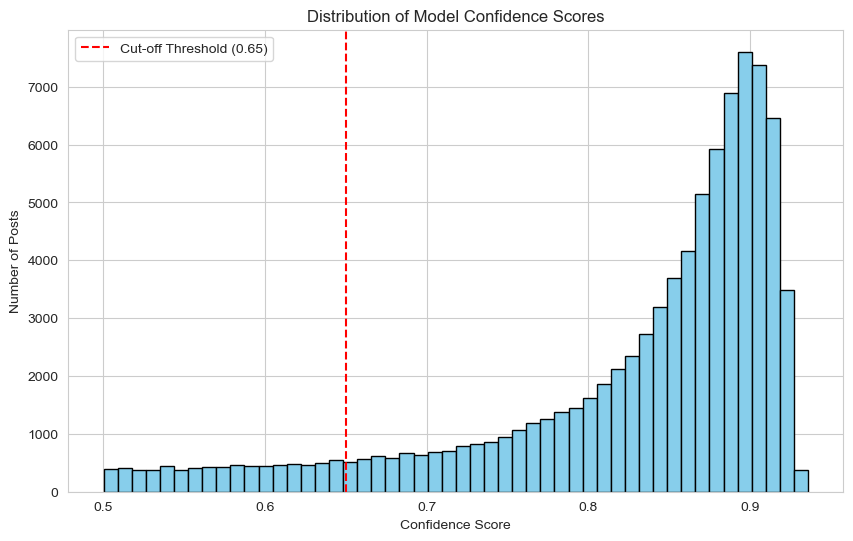

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['script_confidence'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=0.65, color='red', linestyle='--', label='Cut-off Threshold (0.65)')
plt.title("Distribution of Model Confidence Scores")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Posts")
plt.legend()
plt.show()

### Coverage at Different Thresholds

Shows how many posts survive at the 0.65 and 0.60 confidence cut-offs vs. the total corpus size.

In [10]:
from pprint import pprint

pprint(df[df['script_confidence'] > 0.65].shape)
pprint(df[df['script_confidence'] > 0.60].shape)
pprint(df.shape)

(79615, 15)
(82396, 15)
(87155, 15)
